# Towards Optimal Long Jump Strategy

This simulation is designed to generate optimal long jump strategies for athletes based on their historical performance and specific meet situations.

The paper presents a novel approach to long jump strategy, challenging the conventional wisdom of always attempting standard jumps. Instead, it proposes that athletes, especially top performers, can improve their chances of winning by strategically choosing between conservative and standard jumps.

In this notebook we:
* Model athlete performance using mean and standard deviation
for conservative and standard jumps
* Simulate meet structures (e.g., preliminary and final rounds) for various types of meets including the Olympics
* Generate and evaluating all possible jump strategies
* Calculate probabilities for achieving various goals (winning, top-three finish, qualifying for finals)
* Visualize the optimal strategy

We show that our simulation has the potential to improve performance by approximately 1% for top athletes, as demonstrated in the case study of Malaika Mihambo at the 2024 Paris Olympics.

# Simple meet structure: One round

## Simple competition: One jump, two jumpers

This simulation models an extremely simplified long jump competition between two athletes. Each athlete takes only one jump, with their performances characterized by a normal distribution. The first jumper has an average jump distance of 7 meters, while the second jumper's average is 6.9 meters. Both jumpers have a standard deviation of 20 centimeters in their performances, reflecting the variability in their jumps.

In [ ]:
# Simulate only once

import numpy as np

# Set random seed for reproducibility
np.random.seed(52)

# Define jumper parameters - all numbers in meters
jumper1_mean = 7.0
jumper2_mean = 6.9
std_dev = 0.2

# Simulate jumps
jumper1_distance = np.random.normal(jumper1_mean, std_dev)
jumper2_distance = np.random.normal(jumper2_mean, std_dev)

# Determine the winner - disregard ties
if jumper1_distance > jumper2_distance:
    winner = "Jumper 1"
else:
    winner = "Jumper 2"

# Print results
print(f"Jumper 1 distance: {jumper1_distance:.2f} meters")
print(f"Jumper 2 distance: {jumper2_distance:.2f} meters")
print(f"The winner is {winner}")



Jumper 1 distance: 7.10 meters
Jumper 2 distance: 6.65 meters
The winner is Jumper 1


In [ ]:
# Simulate 100,000 times and print probability of jumper 1 winning
num_simulations = 100000
jumper1_wins = 0

for _ in range(num_simulations):
    if np.random.normal(jumper1_mean, std_dev) > np.random.normal(jumper2_mean, std_dev):
        jumper1_wins += 1

probability_jumper1_wins = jumper1_wins / num_simulations
print(f"Probability of Jumper 1 winning: {probability_jumper1_wins:.2%}")

Probability of Jumper 1 winning: 63.87%


In [ ]:
# This situation is simple enough that it can be solved using basic statistics
# Use z score

import numpy as np
import scipy.stats as stats

# Define the distributions
jumper1_distribution = stats.norm(jumper1_mean, std_dev)
jumper2_distribution = stats.norm(jumper2_mean, std_dev)

mean_diff = jumper1_mean - jumper2_mean
std_dev_diff = np.sqrt(std_dev**2 + std_dev**2)  # Since both are independent

# Find P(X > 0) for the normal distribution with mean_diff and std_dev_diff
probability = 1 - stats.norm.cdf(0, loc=mean_diff, scale=std_dev_diff)

print(f"The probability that the jumper who jumps {jumper1_mean} meters beats the jumper who jumps {jumper2_mean} meters is approximately {probability:.2%}")



The probability that the jumper who jumps 7.0 meters beats the jumper who jumps 6.9 meters is approximately 63.82%


## One jump, N jumpers

Generalize:
- Allow an arbitrary number of jumpers
- Allow different standard deviations

In [ ]:
from typing import List, Tuple

def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float]], num_simulations: int = 100000) -> None:
    np.random.seed(52)

    num_jumpers = len(jumper_params)

    # Simulate one competition
    jumps = np.array([np.random.normal(mean, std_dev) for _, mean, std_dev in jumper_params])
    winner_index = np.argmax(jumps)

    # Print results of single competition
    print("Single Competition Results:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name} distance: {jumps[i]:.2f} meters")
    print(f"The winner is {jumper_params[winner_index][0]}\n")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(num_jumpers)

    for _ in range(num_simulations):
        simulated_jumps = np.array([np.random.normal(mean, std_dev) for _, mean, std_dev in jumper_params])
        winner = np.argmax(simulated_jumps)
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("Win Probabilities:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Jumper name, jump mean distance, jump standard deviation
jumpers = [
    ("Jumper 1", 7.0, 0.2),
    ("Jumper 2", 6.9, 0.2),
    ("Jumper 3", 7.1, 0.15),
    ("Jumper 4", 6.8, 0.25),
    # Add more jumpers as needed
]

simulate_long_jump_competition(jumpers)

Single Competition Results:
Jumper 1 distance: 7.10 meters
Jumper 2 distance: 6.65 meters
Jumper 3 distance: 7.14 meters
Jumper 4 distance: 6.60 meters
The winner is Jumper 3

Win Probabilities:
Jumper 1: 27.13%
Jumper 2: 13.03%
Jumper 3: 50.63%
Jumper 4: 9.20%


## N rounds, N Jumpers

Generalize so that there are now N rounds (jumps). The winner is the athlete who jumps the furthest across all N jumps.

In [ ]:
def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float]], num_jumps: int, num_simulations: int = 100000) -> None:
    np.random.seed(2024)

    num_jumpers = len(jumper_params)

    # Simulate one competition
    all_jumps = np.array([[np.random.normal(mean, std_dev) for _ in range(num_jumps)] for _, mean, std_dev in jumper_params])
    best_jumps = np.max(all_jumps, axis=1)
    winner_index = np.argmax(best_jumps)

    # Print results of single competition
    print("Single Competition Results:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name} best distance: {best_jumps[i]:.2f} meters")
    print(f"The winner is {jumper_params[winner_index][0]}\n")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(num_jumpers)

    for _ in range(num_simulations):
        simulated_jumps = np.array([[np.random.normal(mean, std_dev) for _ in range(num_jumps)] for _, mean, std_dev in jumper_params])
        best_simulated_jumps = np.max(simulated_jumps, axis=1)
        winner = np.argmax(best_simulated_jumps)
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("Win Probabilities:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Example usage
jumpers = [
    ("Jumper 1", 7.0, 0.2),
    ("Jumper 2", 6.9, 0.2),
    ("Jumper 3", 7.1, 0.15),
    ("Jumper 4", 6.8, 0.25),
    # Add more jumpers as needed
]

num_jumps = 3  # Set the number of jumps for each athlete

simulate_long_jump_competition(jumpers, num_jumps)

Single Competition Results:
Jumper 1 best distance: 7.33 meters
Jumper 2 best distance: 7.13 meters
Jumper 3 best distance: 7.17 meters
Jumper 4 best distance: 7.21 meters
The winner is Jumper 1

Win Probabilities:
Jumper 1: 30.06%
Jumper 2: 11.67%
Jumper 3: 48.26%
Jumper 4: 10.01%


# Standard meet structure: one prelim round, one final round

In this section, we simulate the standard meet structure:
- There is a preliminary round and a final round.
- Only the top jumpers from the preliminary round make it to the final round.
- The jumpers are ranked based on all of their jumps.

Typically, there are three jumps in the preliminary round and three jumps in the final round.

This is the "standard" meet structure. It is used, for example, at the NCAA championships.

Note that there are many "small" rules, such as tiebreakers, that are not implemented in this simulation

## No strategy

Each jumper has only one kind of jump.

In [ ]:
import numpy as np
from typing import List, Tuple

def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float]],
                                   K: int, M: int, N: int, L: int,
                                   num_simulations: int = 100000) -> None:
    np.random.seed(5)

    def simulate_round(jumpers, num_jumps):
        return np.array([[np.random.normal(mean, std_dev) for _ in range(num_jumps)] for _, mean, std_dev in jumpers])

    # Simulate one competition
    prelim_jumps = simulate_round(jumper_params, M)
    best_prelim_jumps = np.max(prelim_jumps, axis=1)
    finalists_indices = np.argsort(best_prelim_jumps)[-L:][::-1]

    final_jumps = simulate_round([jumper_params[i] for i in finalists_indices], N)
    best_final_jumps = np.max(final_jumps, axis=1)

    overall_best_jumps = np.maximum(best_prelim_jumps[finalists_indices], best_final_jumps)
    winner_index = finalists_indices[np.argmax(overall_best_jumps)]

    # Print results of single competition
    print("Single Competition Results:")
    print("Preliminary Round:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name} best distance: {best_prelim_jumps[i]:.2f} meters")
    print("\nFinal Round:")
    for i, index in enumerate(finalists_indices):
        name = jumper_params[index][0]
        print(f"{name} best distance: {overall_best_jumps[i]:.2f} meters")
    print(f"\nThe winner is {jumper_params[winner_index][0]}")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(K)

    for _ in range(num_simulations):
        prelim_jumps = simulate_round(jumper_params, M)
        best_prelim_jumps = np.max(prelim_jumps, axis=1)
        finalists_indices = np.argsort(best_prelim_jumps)[-L:][::-1]

        final_jumps = simulate_round([jumper_params[i] for i in finalists_indices], N)
        best_final_jumps = np.max(final_jumps, axis=1)

        overall_best_jumps = np.maximum(best_prelim_jumps[finalists_indices], best_final_jumps)
        winner = finalists_indices[np.argmax(overall_best_jumps)]
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("\nWin Probabilities:")
    for i, (name, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Number of athletes, number of prelim jumps, number of final jumps, number of athletes who go to final
K, M, N, L = 30, 3, 3, 8

jumpers = [
    ("Jumper 1", 7.0, 0.2),
    ("Jumper 2", 6.9, 0.2),
    ("Jumper 3", 7.1, 0.15),
    ("Jumper 4", 6.8, 0.25),
    # Add more jumpers to reach K
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2) for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.49 meters
Jumper 2 best distance: 7.22 meters
Jumper 3 best distance: 7.13 meters
Jumper 4 best distance: 6.75 meters
Jumper 5 best distance: 6.88 meters
Jumper 6 best distance: 7.15 meters
Jumper 7 best distance: 6.90 meters
Jumper 8 best distance: 6.83 meters
Jumper 9 best distance: 6.98 meters
Jumper 10 best distance: 6.86 meters
Jumper 11 best distance: 6.74 meters
Jumper 12 best distance: 6.78 meters
Jumper 13 best distance: 7.26 meters
Jumper 14 best distance: 7.26 meters
Jumper 15 best distance: 6.92 meters
Jumper 16 best distance: 7.15 meters
Jumper 17 best distance: 6.96 meters
Jumper 18 best distance: 6.78 meters
Jumper 19 best distance: 6.78 meters
Jumper 20 best distance: 7.17 meters
Jumper 21 best distance: 6.70 meters
Jumper 22 best distance: 7.06 meters
Jumper 23 best distance: 7.09 meters
Jumper 24 best distance: 6.93 meters
Jumper 25 best distance: 7.32 meters
Jumper 26 best distance: 7.01 meters


## Strategy: Standard jump and conservative jump

Now each jumper can choose between a standard jump and a conservative jump.

The standard jump is longer than the conservative jump.

However, a new parameter now determines whether or not the jumper has faulted on a jump. This parameter is higher for a standard jump than a conservative jump.

So the jumper now has to tradeoff between (1) a conservative jump with a shorter distance and with a higher chance of being valid and (2) a standard jump with a longer distance but with a lower chance of being valid.

In [ ]:
def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float, str]],
                                   K: int, M: int, N: int, L: int,
                                   conservative_diff: float = 0.2,
                                   conservative_valid_prob: float = 0.99,
                                   standard_valid_prob: float = 0.8,
                                   num_simulations: int = 100000) -> None:
    np.random.seed(5)

    def simulate_jump(mean, std_dev, is_conservative):
        is_valid = np.random.random() < (conservative_valid_prob if is_conservative else standard_valid_prob)
        if is_valid:
            return np.random.normal(mean - (conservative_diff if is_conservative else 0), std_dev)
        else:
            return -1 # Invalid jump is a distance of -1, this is a bit of a kludge

    def simulate_round(jumpers, num_jumps):
        results = []
        for name, mean, std_dev, strategy in jumpers:
            jumps = []
            for i in range(num_jumps):
                is_conservative = strategy[i] == 'C'
                jumps.append(simulate_jump(mean, std_dev, is_conservative))
            results.append(jumps)
        return np.array(results)

    # Simulate one competition
    prelim_jumps = simulate_round(jumper_params, M)
    best_prelim_jumps = np.max(prelim_jumps, axis=1)
    finalists_indices = np.argsort(best_prelim_jumps)[-L:][::-1]

    final_jumps = simulate_round([jumper_params[i] for i in finalists_indices], N)
    best_final_jumps = np.max(final_jumps, axis=1)

    overall_best_jumps = np.maximum(best_prelim_jumps[finalists_indices], best_final_jumps)
    winner_index = finalists_indices[np.argmax(overall_best_jumps)]

    # Print results of single competition
    print("Single Competition Results:")
    print("Preliminary Round:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name} best distance: {best_prelim_jumps[i]:.2f} meters")
    print("\nFinal Round:")
    for i, index in enumerate(finalists_indices):
        name = jumper_params[index][0]
        print(f"{name} best distance: {overall_best_jumps[i]:.2f} meters")
    print(f"\nThe winner is {jumper_params[winner_index][0]}")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(K)

    for _ in range(num_simulations):
        prelim_jumps = simulate_round(jumper_params, M)
        best_prelim_jumps = np.max(prelim_jumps, axis=1)
        finalists_indices = np.argsort(best_prelim_jumps)[-L:][::-1]

        final_jumps = simulate_round([jumper_params[i] for i in finalists_indices], N)
        best_final_jumps = np.max(final_jumps, axis=1)

        overall_best_jumps = np.maximum(best_prelim_jumps[finalists_indices], best_final_jumps)
        winner = finalists_indices[np.argmax(overall_best_jumps)]
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("\nWin Probabilities:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Number of athletes, number of prelim jumps, number of final jumps, number of athletes who go to final
K, M, N, L = 30, 3, 3, 8

# Note: this code will only work when M+N = 6
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.1, 0.15, "SSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.07 meters
Jumper 2 best distance: 7.22 meters
Jumper 3 best distance: 7.19 meters
Jumper 4 best distance: 7.26 meters
Jumper 5 best distance: 6.78 meters
Jumper 6 best distance: 6.98 meters
Jumper 7 best distance: 7.05 meters
Jumper 8 best distance: 6.64 meters
Jumper 9 best distance: 6.74 meters
Jumper 10 best distance: 6.70 meters
Jumper 11 best distance: 7.11 meters
Jumper 12 best distance: 6.83 meters
Jumper 13 best distance: 6.59 meters
Jumper 14 best distance: 7.03 meters
Jumper 15 best distance: 6.81 meters
Jumper 16 best distance: 7.12 meters
Jumper 17 best distance: 7.24 meters
Jumper 18 best distance: 7.20 meters
Jumper 19 best distance: 6.84 meters
Jumper 20 best distance: 7.17 meters
Jumper 21 best distance: 6.90 meters
Jumper 22 best distance: 7.06 meters
Jumper 23 best distance: 6.60 meters
Jumper 24 best distance: 7.24 meters
Jumper 25 best distance: 7.36 meters
Jumper 26 best distance: 6.47 meters


### Jumper 3 is 10cm better

When Jumper 3 is 10cm, a typical advantage for the best jumper in a competition, Jumper 3 should not make any conservative jumps.


In [ ]:
# Compare strategies for Jumper 3 which is the best 'defined' jumper
# SSSSSS win probability vs CCCCCC win probability
# SSSSSS win probability = 26.96%
# CCCCCC win probability = 1.24%

np.random.seed(5)

# Jumper 3 SSSSSS
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.1, 0.15, "SSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

# Jumper 3 CCCCCC
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.1, 0.15, "CCCCCC"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.07 meters
Jumper 2 best distance: 7.22 meters
Jumper 3 best distance: 7.19 meters
Jumper 4 best distance: 7.26 meters
Jumper 5 best distance: 6.81 meters
Jumper 6 best distance: 6.94 meters
Jumper 7 best distance: 6.67 meters
Jumper 8 best distance: 7.01 meters
Jumper 9 best distance: 6.97 meters
Jumper 10 best distance: 6.90 meters
Jumper 11 best distance: 7.14 meters
Jumper 12 best distance: 6.70 meters
Jumper 13 best distance: 6.73 meters
Jumper 14 best distance: 6.83 meters
Jumper 15 best distance: 6.85 meters
Jumper 16 best distance: 7.23 meters
Jumper 17 best distance: 7.14 meters
Jumper 18 best distance: 6.78 meters
Jumper 19 best distance: 7.15 meters
Jumper 20 best distance: 6.90 meters
Jumper 21 best distance: 6.67 meters
Jumper 22 best distance: 6.75 meters
Jumper 23 best distance: 6.91 meters
Jumper 24 best distance: 7.29 meters
Jumper 25 best distance: 7.17 meters
Jumper 26 best distance: 6.41 meters


In [ ]:
# Compare strategies for Jumper which is the best 'defined' jumper
# SSSSSS win probability vs CSSSSS win probability
# SSSSSS win probability = 26.96%
# CSSSSS win probability = 14.64%
# Illustrates that cost of conservative jump in standard structure is too high

np.random.seed(5)

# Jumper 3 SSSSSS
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.1, 0.15, "SSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

# Jumper 3 CSSSSS
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.1, 0.15, "CSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.07 meters
Jumper 2 best distance: 7.22 meters
Jumper 3 best distance: 7.19 meters
Jumper 4 best distance: 7.26 meters
Jumper 5 best distance: 6.81 meters
Jumper 6 best distance: 6.94 meters
Jumper 7 best distance: 6.67 meters
Jumper 8 best distance: 7.01 meters
Jumper 9 best distance: 6.97 meters
Jumper 10 best distance: 6.90 meters
Jumper 11 best distance: 7.14 meters
Jumper 12 best distance: 6.70 meters
Jumper 13 best distance: 6.73 meters
Jumper 14 best distance: 6.83 meters
Jumper 15 best distance: 6.85 meters
Jumper 16 best distance: 7.23 meters
Jumper 17 best distance: 7.14 meters
Jumper 18 best distance: 6.78 meters
Jumper 19 best distance: 7.15 meters
Jumper 20 best distance: 6.90 meters
Jumper 21 best distance: 6.67 meters
Jumper 22 best distance: 6.75 meters
Jumper 23 best distance: 6.91 meters
Jumper 24 best distance: 7.29 meters
Jumper 25 best distance: 7.17 meters
Jumper 26 best distance: 6.41 meters


### Jumper 3 is 50cm better

In [ ]:
# Compare strategies for Jumper which is the best 'defined' jumper
# SSSSSS win probability vs CSSSSS win probability
# SSSSSS win probability = 26.96%
# CSSSSS win probability = 14.64%
# Illustrates that cost of conservative jump in standard structure is too high

np.random.seed(5)

# Jumper 3 SSSSSS
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 8, 0.15, "SSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

# Jumper 3 CSSSSS
jumpers = [
    ("Jumper 1", 7.0, 0.2, "SSSSSS"),
    ("Jumper 2", 6.9, 0.2, "SSSSSS"),
    ("Jumper 3", 7.5, 0.15, "CSSSSS"),
    ("Jumper 4", 6.8, 0.25, "SSSSSS"),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "SSSSSS") for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, N, L)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.07 meters
Jumper 2 best distance: 7.22 meters
Jumper 3 best distance: 8.09 meters
Jumper 4 best distance: 7.26 meters
Jumper 5 best distance: 6.81 meters
Jumper 6 best distance: 6.94 meters
Jumper 7 best distance: 6.67 meters
Jumper 8 best distance: 7.01 meters
Jumper 9 best distance: 6.97 meters
Jumper 10 best distance: 6.90 meters
Jumper 11 best distance: 7.14 meters
Jumper 12 best distance: 6.70 meters
Jumper 13 best distance: 6.73 meters
Jumper 14 best distance: 6.83 meters
Jumper 15 best distance: 6.85 meters
Jumper 16 best distance: 7.23 meters
Jumper 17 best distance: 7.14 meters
Jumper 18 best distance: 6.78 meters
Jumper 19 best distance: 7.15 meters
Jumper 20 best distance: 6.90 meters
Jumper 21 best distance: 6.67 meters
Jumper 22 best distance: 6.75 meters
Jumper 23 best distance: 6.91 meters
Jumper 24 best distance: 7.29 meters
Jumper 25 best distance: 7.17 meters
Jumper 26 best distance: 6.41 meters


# Olympic structure: one prelim round, one final A round, one final B round with strategy

In the Olympics, the top 12 jumpers[1] make it to the final round (which we call round A). They then get an additional three jumps and the top 8 jumpers get an additional three jumps (which we call round B).

The winner is determined only by the jumps in the final round. Unlike the standard meet structure (see above), preliminary jumps are not counted in determining the winner.

There are three jumps in the preliminary round.

[1] This is a slight simplification. Technically, all jumpers who meet a certain standard make the final round. However, as a practical matter, fewer than a handful of jumpers meet the standard.

In [ ]:
def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float, str]],
                                   K: int, M: int, LA: int, LB: int, NA: int, NB: int,
                                   conservative_diff: float = 0.2,
                                   conservative_valid_prob: float = 0.99,
                                   standard_valid_prob: float = 0.8,
                                   num_simulations: int = 100000) -> None:
    np.random.seed(5)

    def simulate_jump(mean, std_dev, is_conservative):
        is_valid = np.random.random() < (conservative_valid_prob if is_conservative else standard_valid_prob)
        if is_valid:
            return np.random.normal(mean - (conservative_diff if is_conservative else 0), std_dev)
        else:
            return -1

    def simulate_round(jumpers, num_jumps, start_index):
        results = []
        for name, mean, std_dev, strategy in jumpers:
            jumps = []
            for i in range(num_jumps):
                is_conservative = strategy[start_index + i] == 'C'
                jumps.append(simulate_jump(mean, std_dev, is_conservative))
            results.append(jumps)
        return np.array(results)

    # Simulate one competition
    prelim_jumps = simulate_round(jumper_params, M, 0)
    best_prelim_jumps = np.max(prelim_jumps, axis=1)
    round_a_indices = np.argsort(best_prelim_jumps)[-LA:][::-1]

    round_a_jumps = simulate_round([jumper_params[i] for i in round_a_indices], NA, M)
    best_round_a_jumps = np.max(round_a_jumps, axis=1)
    round_b_indices = np.argsort(best_round_a_jumps)[-LB:][::-1]

    round_b_jumps = simulate_round([jumper_params[round_a_indices[i]] for i in round_b_indices], NB, M + NA)
    best_round_b_jumps = np.max(round_b_jumps, axis=1)

    overall_best_jumps = np.maximum(best_round_a_jumps[round_b_indices], best_round_b_jumps)
    winner_index = round_a_indices[round_b_indices[np.argmax(overall_best_jumps)]]

    # Print results of single competition
    print("Single Competition Results:")
    print("Preliminary Round:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name} best distance: {best_prelim_jumps[i]:.2f} meters")
    print("\nFinal Round A:")
    for i, index in enumerate(round_a_indices):
        name = jumper_params[index][0]
        print(f"{name} best distance: {best_round_a_jumps[i]:.2f} meters")
    print("\nFinal Round B:")
    for i, index in enumerate(round_b_indices):
        name = jumper_params[round_a_indices[index]][0]
        print(f"{name} best distance: {overall_best_jumps[i]:.2f} meters")
    print(f"\nThe winner is {jumper_params[winner_index][0]}")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(K)

    for _ in range(num_simulations):
        prelim_jumps = simulate_round(jumper_params, M, 0)
        best_prelim_jumps = np.max(prelim_jumps, axis=1)
        round_a_indices = np.argsort(best_prelim_jumps)[-LA:][::-1]

        round_a_jumps = simulate_round([jumper_params[i] for i in round_a_indices], NA, M)
        best_round_a_jumps = np.max(round_a_jumps, axis=1)
        round_b_indices = np.argsort(best_round_a_jumps)[-LB:][::-1]

        round_b_jumps = simulate_round([jumper_params[round_a_indices[i]] for i in round_b_indices], NB, M + NA)
        best_round_b_jumps = np.max(round_b_jumps, axis=1)

        overall_best_jumps = np.maximum(best_round_a_jumps[round_b_indices], best_round_b_jumps)
        winner = round_a_indices[round_b_indices[np.argmax(overall_best_jumps)]]
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("\nWin Probabilities:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Example usage
K, M, LA, LB, NA, NB = 30, 3, 12, 8, 3, 3
total_jumps = M + NA + NB

# All S is standard strategy
jumpers = [
    ("Jumper 1", 7.0, 0.2, "S" * total_jumps),
    ("Jumper 2", 6.9, 0.2, "S" * total_jumps),
    ("Jumper 3", 7.1, 0.15, "S" * total_jumps),
    ("Jumper 4", 6.8, 0.25, "S" * total_jumps),
    # Add more jumpers to reach K=30
] + [("Jumper " + str(i+5), 6.5 + np.random.rand()*0.5, 0.2, "S" * total_jumps) for i in range(K-4)]

simulate_long_jump_competition(jumpers, K, M, LA, LB, NA, NB)

Single Competition Results:
Preliminary Round:
Jumper 1 best distance: 7.12 meters
Jumper 2 best distance: 6.89 meters
Jumper 3 best distance: 7.20 meters
Jumper 4 best distance: 6.59 meters
Jumper 5 best distance: 6.70 meters
Jumper 6 best distance: 6.88 meters
Jumper 7 best distance: 7.10 meters
Jumper 8 best distance: 7.01 meters
Jumper 9 best distance: 6.92 meters
Jumper 10 best distance: 7.09 meters
Jumper 11 best distance: 6.76 meters
Jumper 12 best distance: 7.35 meters
Jumper 13 best distance: 6.88 meters
Jumper 14 best distance: 7.02 meters
Jumper 15 best distance: 6.92 meters
Jumper 16 best distance: 6.80 meters
Jumper 17 best distance: 6.76 meters
Jumper 18 best distance: 6.72 meters
Jumper 19 best distance: 7.41 meters
Jumper 20 best distance: 6.89 meters
Jumper 21 best distance: 6.40 meters
Jumper 22 best distance: 6.90 meters
Jumper 23 best distance: 6.39 meters
Jumper 24 best distance: 6.74 meters
Jumper 25 best distance: 7.16 meters
Jumper 26 best distance: 6.98 meters


In [ ]:
# Model of 2024 Olympics

def simulate_long_jump_competition(jumper_params: List[Tuple[str, float, float, str]],
                                   K: int, M: int, LA: int, LB: int, NA: int, NB: int,
                                   conservative_diff: float = 0.2,
                                   conservative_valid_prob: float = 0.99,
                                   standard_valid_prob: float = 0.8,
                                   num_simulations: int = 10000) -> None:
    np.random.seed(5)

    def simulate_jump(mean, std_dev, is_conservative):
        is_valid = np.random.random() < (conservative_valid_prob if is_conservative else standard_valid_prob)
        if is_valid:
            return np.random.normal(mean - (conservative_diff if is_conservative else 0), std_dev)
        else:
            return -1

    def simulate_round(jumpers, num_jumps, start_index):
        results = []
        for name, mean, std_dev, strategy in jumpers:
            jumps = []
            for i in range(num_jumps):
                is_conservative = strategy[start_index + i] == 'C'
                jumps.append(simulate_jump(mean, std_dev, is_conservative))
            results.append(jumps)
        return np.array(results)

    # Simulate one competition
    prelim_jumps = simulate_round(jumper_params, M, 0)
    best_prelim_jumps = np.max(prelim_jumps, axis=1)
    round_a_indices = np.argsort(best_prelim_jumps)[-LA:][::-1]

    round_a_jumps = simulate_round([jumper_params[i] for i in round_a_indices], NA, M)
    best_round_a_jumps = np.max(round_a_jumps, axis=1)
    round_b_indices = np.argsort(best_round_a_jumps)[-LB:][::-1]

    round_b_jumps = simulate_round([jumper_params[round_a_indices[i]] for i in round_b_indices], NB, M + NA)
    best_round_b_jumps = np.max(round_b_jumps, axis=1)

    overall_best_jumps = np.maximum(best_round_a_jumps[round_b_indices], best_round_b_jumps)
    winner_index = round_a_indices[round_b_indices[np.argmax(overall_best_jumps)]]

    # Print results of single competition
    print("Single Competition Results:")
    print("Preliminary Round:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name} best distance: {best_prelim_jumps[i]:.2f} meters")
    print("\nFinal Round A:")
    for i, index in enumerate(round_a_indices):
        name = jumper_params[index][0]
        print(f"{name} best distance: {best_round_a_jumps[i]:.2f} meters")
    print("\nFinal Round B:")
    for i, index in enumerate(round_b_indices):
        name = jumper_params[round_a_indices[index]][0]
        print(f"{name} best distance: {overall_best_jumps[i]:.2f} meters")
    print(f"\nThe winner is {jumper_params[winner_index][0]}")

    # Run multiple simulations to calculate win probabilities
    win_counts = np.zeros(K)

    for _ in range(num_simulations):
        prelim_jumps = simulate_round(jumper_params, M, 0)
        best_prelim_jumps = np.max(prelim_jumps, axis=1)
        round_a_indices = np.argsort(best_prelim_jumps)[-LA:][::-1]

        round_a_jumps = simulate_round([jumper_params[i] for i in round_a_indices], NA, M)
        best_round_a_jumps = np.max(round_a_jumps, axis=1)
        round_b_indices = np.argsort(best_round_a_jumps)[-LB:][::-1]

        round_b_jumps = simulate_round([jumper_params[round_a_indices[i]] for i in round_b_indices], NB, M + NA)
        best_round_b_jumps = np.max(round_b_jumps, axis=1)

        overall_best_jumps = np.maximum(best_round_a_jumps[round_b_indices], best_round_b_jumps)
        winner = round_a_indices[round_b_indices[np.argmax(overall_best_jumps)]]
        win_counts[winner] += 1

    win_probabilities = win_counts / num_simulations

    # Print win probabilities
    print("\nWin Probabilities:")
    for i, (name, _, _, _) in enumerate(jumper_params):
        print(f"{name}: {win_probabilities[i]:.2%}")

# Prelim jumps, number of athletes to A round, number of athletes B round,
# number of jumps in A round, number of jumps in B round
M, LA, LB, NA, NB = 3, 12, 8, 3, 3
total_jumps = M + NA + NB



Single Competition Results:
Preliminary Round:
Tara Davis-Woodhall best distance: 6.93 meters
Larissa Iapichino best distance: 7.12 meters
Malaika Mihambo best distance: 7.22 meters
Ese Brume best distance: 6.96 meters
Ruth Usoro best distance: 6.63 meters
Jasmine Moore best distance: 6.75 meters
Prestina Ochonogor best distance: 6.36 meters
Monae' Nichols best distance: 6.62 meters
Alina Rotaru-Kottmann best distance: 6.77 meters
Ackelia Smith best distance: 6.53 meters
Marthe Koala best distance: 6.78 meters
Hilary Kpatcha best distance: 6.08 meters
Xiong Shiqi best distance: 6.63 meters
Pauline Hondema best distance: 6.07 meters
Fátima Diame best distance: 6.76 meters
Ivana Španović best distance: 6.77 meters
Chanice Porter best distance: 6.77 meters
Milica Gardašević best distance: 6.68 meters
Plamena Mitkova best distance: 6.61 meters
Laura Raquel Müller best distance: 6.57 meters
Petra Farkas best distance: 6.29 meters
Natalia Linares best distance: 6.32 meters
Eliane Martins bes

### Key result: Malaika 81.51% (SSS) vs 82.43% (CSS)

In [ ]:
# Malaika SSS vs CSS
# SSS win probability = 81.51%
# CSS win probability = 82.43%

# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 7.1, 0.2, 'SSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)


# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 7.1, 0.2, 'CSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)

Single Competition Results:
Preliminary Round:
Tara Davis-Woodhall best distance: 6.93 meters
Larissa Iapichino best distance: 7.12 meters
Malaika Mihambo best distance: 7.22 meters
Ese Brume best distance: 6.96 meters
Ruth Usoro best distance: 6.63 meters
Jasmine Moore best distance: 6.75 meters
Prestina Ochonogor best distance: 6.36 meters
Monae' Nichols best distance: 6.62 meters
Alina Rotaru-Kottmann best distance: 6.77 meters
Ackelia Smith best distance: 6.53 meters
Marthe Koala best distance: 6.78 meters
Hilary Kpatcha best distance: 6.08 meters
Xiong Shiqi best distance: 6.63 meters
Pauline Hondema best distance: 6.07 meters
Fátima Diame best distance: 6.76 meters
Ivana Španović best distance: 6.77 meters
Chanice Porter best distance: 6.77 meters
Milica Gardašević best distance: 6.68 meters
Plamena Mitkova best distance: 6.61 meters
Laura Raquel Müller best distance: 6.57 meters
Petra Farkas best distance: 6.29 meters
Natalia Linares best distance: 6.32 meters
Eliane Martins bes

In [ ]:
# Malaika jump drops to 7.0m, result still holds even though the advantage is smaller
# Malaika SSS vs CSS
# SSS win probability = 63.82%
# CSS win probability = 64.66%

# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 6.9, 0.2, 'SSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)


# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 6.9, 0.2, 'CSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)

Single Competition Results:
Preliminary Round:
Tara Davis-Woodhall best distance: 6.93 meters
Larissa Iapichino best distance: 7.12 meters
Malaika Mihambo best distance: 7.02 meters
Ese Brume best distance: 6.96 meters
Ruth Usoro best distance: 6.63 meters
Jasmine Moore best distance: 6.75 meters
Prestina Ochonogor best distance: 6.36 meters
Monae' Nichols best distance: 6.62 meters
Alina Rotaru-Kottmann best distance: 6.77 meters
Ackelia Smith best distance: 6.53 meters
Marthe Koala best distance: 6.78 meters
Hilary Kpatcha best distance: 6.08 meters
Xiong Shiqi best distance: 6.63 meters
Pauline Hondema best distance: 6.07 meters
Fátima Diame best distance: 6.76 meters
Ivana Španović best distance: 6.77 meters
Chanice Porter best distance: 6.77 meters
Milica Gardašević best distance: 6.68 meters
Plamena Mitkova best distance: 6.61 meters
Laura Raquel Müller best distance: 6.57 meters
Petra Farkas best distance: 6.29 meters
Natalia Linares best distance: 6.32 meters
Eliane Martins bes

In [ ]:
# Malaika jump drops to 6.9m, result no longer holds
# Malaika SSS vs CSS
# SSS win probability = 42.05%
# CSS win probability = 41.95%

# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 6.9, 0.2, 'SSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)


# All S is standard strategy
jumpers = [
        ("Tara Davis-Woodhall", 6.86, 0.2, 'SSSSSSSSS'),
        ("Larissa Iapichino", 6.80, 0.2, 'SSSSSSSSS'),
        ("Malaika Mihambo", 6.9, 0.2, 'CSSSSSSSS'),
        ("Ese Brume", 6.59, 0.2, 'SSSSSSSSS'),
        ("Ruth Usoro", 6.43, 0.2, 'SSSSSSSSS'),
        ("Jasmine Moore", 6.75, 0.2, 'SSSSSSSSS'),
        ("Prestina Ochonogor", 6.29, 0.2, 'SSSSSSSSS'),
        ("Monae' Nichols", 6.57, 0.2, 'SSSSSSSSS'),
        ("Alina Rotaru-Kottmann", 6.54, 0.2, 'SSSSSSSSS'),
        ("Ackelia Smith", 6.44, 0.2, 'SSSSSSSSS'),
        ("Marthe Koala", 6.52, 0.2, 'SSSSSSSSS'),
        ("Hilary Kpatcha", 6.14, 0.2, 'SSSSSSSSS'),
        ("Xiong Shiqi", 6.55, 0.2,'SSSSSSSSS'),
        ("Pauline Hondema", 5.83, 0.2, 'SSSSSSSSS'),
        ("Fátima Diame", 6.45, 0.2, 'SSSSSSSSS'),
        ("Ivana Španović", 6.41, 0.2, 'SSSSSSSSS'),
        ("Chanice Porter", 6.35, 0.2, 'SSSSSSSSS'),
        ("Milica Gardašević", 6.48, 0.2, 'SSSSSSSSS'),
        ("Plamena Mitkova", 6.40, 0.2, 'SSSSSSSSS'),
        ("Laura Raquel Müller", 6.30, 0.2, 'SSSSSSSSS'),
        ("Petra Farkas", 6.32, 0.2, 'SSSSSSSSS'),
        ("Natalia Linares", 6.22, 0.2, 'SSSSSSSSS'),
        ("Eliane Martins", 6.36, 0.2, 'SSSSSSSSS'),
        ("Agate de Sousa", 6.31, 0.2, 'SSSSSSSSS'),
        ("Brooke Buschkuehl", 6.23, 0.2, 'SSSSSSSSS'),
        ("Sumire Hata", 6.26, 0.2, 'SSSSSSSSS'),
        ("Nikola Horowska", 6.31, 0.2, 'SSSSSSSSS'),
        ("Mikaelle Assani", 6.00, 0.2, 'SSSSSSSSS'),
        ("Esraa Owis", 6.08, 0.2, 'SSSSSSSSS'),
        ("Tessy Ebosele", 6.06, 0.2, 'SSSSSSSSS'),
        ("Lissandra Campos", 5.96, 0.2, 'SSSSSSSSS')]


simulate_long_jump_competition(jumpers, len(jumpers), M, LA, LB, NA, NB)

Single Competition Results:
Preliminary Round:
Tara Davis-Woodhall best distance: 6.93 meters
Larissa Iapichino best distance: 7.12 meters
Malaika Mihambo best distance: 7.02 meters
Ese Brume best distance: 6.96 meters
Ruth Usoro best distance: 6.63 meters
Jasmine Moore best distance: 6.75 meters
Prestina Ochonogor best distance: 6.36 meters
Monae' Nichols best distance: 6.62 meters
Alina Rotaru-Kottmann best distance: 6.77 meters
Ackelia Smith best distance: 6.53 meters
Marthe Koala best distance: 6.78 meters
Hilary Kpatcha best distance: 6.08 meters
Xiong Shiqi best distance: 6.63 meters
Pauline Hondema best distance: 6.07 meters
Fátima Diame best distance: 6.76 meters
Ivana Španović best distance: 6.77 meters
Chanice Porter best distance: 6.77 meters
Milica Gardašević best distance: 6.68 meters
Plamena Mitkova best distance: 6.61 meters
Laura Raquel Müller best distance: 6.57 meters
Petra Farkas best distance: 6.29 meters
Natalia Linares best distance: 6.32 meters
Eliane Martins bes

# Utility code


## Best of N vs Best of N-1


Median best jump for 1 jumps: 7.1012 meters
Median best jump for 2 jumps: 7.2119 meters
Median best jump for 3 jumps: 7.2673 meters
Median best jump for 4 jumps: 7.3004 meters
Median best jump for 5 jumps: 7.3275 meters
Median best jump for 6 jumps: 7.3448 meters


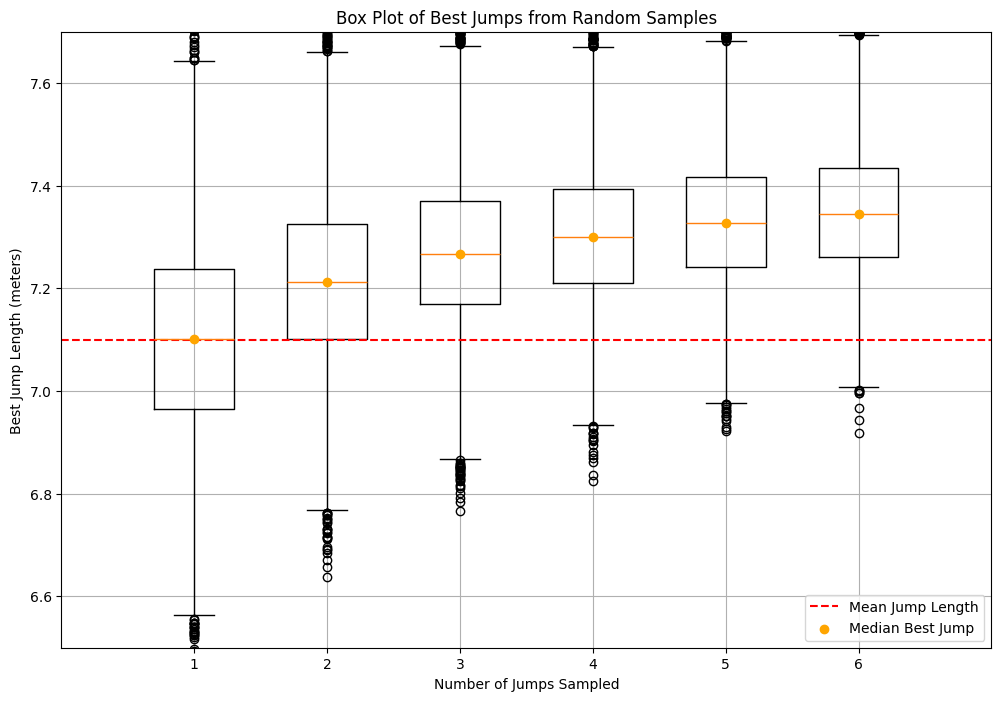

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mean_jump = 7.1      # mean of the jumps in meters
std_dev_jump = 0.2   # standard deviation of jumps in meters (20 cm)
N = 6                # Number of jumps to sample
repetitions = 10000  # Number of simulations

# List to store the best jumps for each sample size
best_jumps = [[] for _ in range(N)]

# Meet simulation
for _ in range(repetitions):
    for num_jumps in range(1, N + 1):
        # Randomly sample jumps from a normal distribution
        jumps = np.random.normal(mean_jump, std_dev_jump, num_jumps)
        # Choose the best jump and store it
        best_jumps[num_jumps - 1].append(np.max(jumps))

# Calculate medians for each sample size
medians = [np.median(best_jump) for best_jump in best_jumps]

# Plotting
plt.figure(figsize=(12, 8))
plt.boxplot(best_jumps, positions=range(1, N + 1), widths=0.6)
plt.title('Box Plot of Best Jumps from Random Samples')
plt.xlabel('Number of Jumps Sampled')
plt.ylabel('Best Jump Length (meters)')
plt.grid()
plt.axhline(y=mean_jump, color='r', linestyle='--', label='Mean Jump Length')
plt.scatter(range(1, N + 1), medians, color='orange', label='Median Best Jump', zorder=5)
plt.legend()
plt.xlim(0, N+1)
plt.ylim(mean_jump - 3 * std_dev_jump, mean_jump + 3 * std_dev_jump)

# Print medians
for i in range(N):
    print(f"Median best jump for {i + 1} jumps: {medians[i]:.4f} meters")

plt.show()